In [392]:

### Libraries
using LinearAlgebra
using DelimitedFiles
using DifferentialEquations
using Tullio
using TensorOperations
⊗(A,B) = kron(A,B) ;

In [32]:
# import Pkg
# Pkg.add("TensorOperations")

### Initial parameters

In [33]:
### Constants
MBOHR = 5.788381e-5         ### Bohrs magneton
KB = 0.00008617343 #8.617333262e-5           ### Bolzmann factor
GAMMA_R = 1.760859644e-4    ### Gyromagnetic ratio ##1 for units of G_r=1
hbar = 1.0#0.658211928e0        ### Planck constant (eV*fs) 
k_Boltzman = 0.00008617343 ;#(eV/K) # 1.3806504d-23 (J/K)
### Parameters and initiallizations
ny = 1
nx = 2
ns = nx*ny
nσ = 2
nk = 50
nα = 2
t = 1
#tc = 1
γ = 1
γso = 0.0
γc = 1.0#0.0
ϵ0 = 0.0#2γ
j_sd = 0.1#0.1
Δ_α = [0.0,0.0]
### Dimensions of the problem
dim_s = ns*nσ#(nx*ns,nx*ns)
dim_e = nk*nσ
dim_α = nα
dims_Gleαs_kαi=(dim_e,dim_α,dim_s)
dims_Gls_ij = (dim_s,dim_s)
dims_Gleα_qkα = (dim_e,dim_e,dim_α)
size_Gleαs_kαi = prod(dims_Gleαs_kαi) 
size_Gls_ij = prod(dims_Gls_ij)
size_Gleα_qkα = prod(dims_Gleα_qkα)
### Pauli matrices
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1])
σ_x =  Matrix{ComplexF64}([0 1; 1 0])
σ_y =  Matrix{ComplexF64}([0 -1im ; 1im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1])

I_a1b1 = Matrix{ComplexF64}(I, ns, ns)           # Identity on lattice space
I_ab = Matrix{ComplexF64}(I, nσ*ns, nσ*ns)        # Identity on lattice ⊗ spin
# --- Pauli matrices extended to the full Hilbert space ---
σ_x1ab = kron(I_a1b1, σ_x)
σ_x2ab = kron(I_a1b1, σ_y)
σ_x3ab = kron(I_a1b1, σ_z)
# --- Pauli matrices as a 3D array σ_abx[μ, i, j] ---
σ_ijx = cat(σ_x1ab, σ_x2ab, σ_x3ab; dims=3)
### Hamiltonians
hs_ij = zeros(ComplexF64, (dim_s,dim_s) )
heα_qkα = zeros(ComplexF64, (dim_e,dim_e,dim_α ))
heαs_kαi = zeros(ComplexF64, (dim_e,dim_α,dim_s) )
hseα_ikα = zeros(ComplexF64, (dim_s,dim_e,dim_α) )
### Green functions
Gleα_qkα = zeros(ComplexF64, (dim_e,dim_e,dim_α) )
### Dynamical variables
Gleαs_kαi = zeros(ComplexF64, dims_Gleαs_kαi  )
Gls_ij = zeros(ComplexF64, dims_Gls_ij );
Gleα_qkα = zeros(ComplexF64,dims_Gleα_qkα);
### Observables

In [34]:
#prod(dims_Gls_ij)
#vec(Gleα_qkα)

In [35]:
#size_Gleαs_kαi+size_Gls_ij-(size_Gleαs_kαi+size_Gls_ij+size_Gleα_qkα) 

#### Pulses

In [36]:
# ### Leviton 
# ts = 0.0:0.1:200
# τ = 6
# t0 = 80
# lev(t;t0 = t0,τ = τ) = 2τ/((t-t0)^2+τ^2)
# plt.plot(ts,lev.(ts))

In [37]:
#gauss(t;A,t0,τ)=A*exp(-(t-t0)^2/(2*τ^2))

In [38]:
#### Initiallizing the dynamical variables 
# σ_ijx 
# σ_x3ab
#LinRange(-pi,pi,nk)
#heα_kα[2:2:end,1]

In [236]:
#### Create electronic Hamiltonian 
function block_h(ny,γ,γso)
    #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
    "Creates the building blocks for a general nx x ny square lattice
    
    Returns:
       H0 :: intra-cell (y direction) Hamiltonian block of size (ny*nσ)×(ny*nσ)
       T  :: inter-cell (x direction) hopping block of same size"
    dim = ny*nσ # We include the spin degree of freedom 
    ######
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end

function hs(vm_i1x::Array{Float64,2},nx,ny,γ,γso,j_sd)
    "This function build the central hamiltonian wwith two band"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    dim = nx*ny*nσ #*2
    zero = zeros(ComplexF64,nx,nx)
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = block_h(ny,γ,γso)
    Tx = diagm( -1 =>  ones(nx-1))⊗T 
    HC = (One_x⊗H0) +  Tx + Tx'
    ### Local moments
    for i in range(1,nx) 
        zero[i,i] = 1.0
        HC += -j_sd*zero⊗(vm_i1x[i,1]*σ_x
                    +vm_i1x[i,2]*σ_y
                    +vm_i1x[i,3]*σ_z)
        zero[i,i] = 0.0
    end
    return HC
end
## Note que el rango en ks se puede mejorar de tal forma de que el punto
## inicial y final no se repitan 

# function heα(ϵα0,γ,nk,nσ)
#     dim_e = nk*nσ
#     dim_α = nα
#     heα_kα = zeros(ComplexF64, (dim_e,dim_α))
#     ks =LinRange(-pi,pi,nk) # range(-π, stop=π, length=nk+1)[1:end-1]#
#     heα_kα[1:2:end,1] .= - 2γ*cos.(ks) .+ ϵα0[1] 
#     heα_kα[2:2:end,1] .= - 2γ*cos.(ks) .+ ϵα0[1] 
    
#     heα_kα[1:2:end,2] .= - 2γ*cos.(ks) .+ ϵα0[2] 
#     heα_kα[2:2:end,2] .= - 2γ*cos.(ks) .+ ϵα0[2] 
#     #he_k = ϵα0*diagm(ones(dim_e))
#     return heα_kα#h_kα
# end

# function hseα(ns,γc,nk,nσ)
#     dim_e = nk*nσ
#     dim_s = ns*nσ
#     ks = LinRange(-pi,pi,nk) #range(-π, stop=π, length=nk+1)[1:end-1]#
#     hseα_ikα = zeros(ComplexF64, (dim_s,dim_e,dim_α) )
#     hseα_ikα[1,1:2:end,1] .= -γc*sin.(ks)*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)
#     hseα_ikα[2,2:2:end,1] .= -γc*sin.(ks)*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)

#     hseα_ikα[end-1,1:2:end,2] .= -γc*sin.(ks)*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)
#     hseα_ikα[end,2:2:end,2] .= -γc*sin.(ks)*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)
#     # hseα_ik[1,1] = 
#     # hseα_ik[1,1] = 
#     return hseα_ikα
# end
# function heα(ϵα0,γ,nk,nσ)
#     dim_e = nk*nσ
#     dim_α = nα
#     heα_qkα = zeros(ComplexF64, (dim_e,dim_e,dim_α))
#     #heα_kα[:,1] = ϵα0*diagm(ones(dim_e))
#     return heα_qkα
# end

function hseα(ns,γc,nk,nσ)
    dim_e = nk*nσ
    dim_s = ns*nσ
    dim_α = nα
    hseα_ikα = zeros(ComplexF64, (dim_s,dim_e,dim_α) )
    # hseα_ikα[1,1,1] = -γc*0.5#*0.0 ########## Disconected
    # hseα_ikα[2,2,1] = -γc*0.5#*0.0 ########## Disconected
    # hseα_ikα[3,1,2] = -γc*0.5#*0.5#*0.2
    # hseα_ikα[4,2,2] = -γc*0.5#*0.5#*0.2

    ### Left
    hseα_ikα[1,end-1,1] = -γc*1.0#*0.0 ########## Disconected
    hseα_ikα[2,end,1] = -γc*1.0#*0.0 ########## Disconected
    ### Right
    hseα_ikα[3,1,2] = -γc*1.0#*0.5#*0.2
    hseα_ikα[4,2,2] = -γc*1.0#*0.5#*0.2
    return hseα_ikα
end


function fermi(ϵ)
    """ Fermi function 
    """
   fermi = 1. / (1. + exp(ϵ))
end



fermi (generic function with 1 method)

In [237]:
# htot = zeros(Float64, (ns*nσ + nk*nσ*nα) )

# nx = 2
# ny = 1
# ns = nx*ny
# nσ = 2
# nα = 2
# nk = 100
# γ = 1.0
# γso = 0.0
# γc = 1.0#1.0#1.0#1.0
# ϵ0 = 0.0#2γ
# Temp = 300#0.01#300#0.1
# j_sd = 0.1
# ### Then, in order to calculate it we should  
# ks = LinRange(-pi,pi,nk) # range(-π, stop=π, length=nk+1)[1:end-1]#
# vm_i1x = zeros(Float64,nx*ny,3)
# heα_qkα = zeros(ComplexF64, (dim_e,dim_e,dim_α ))
# Gleα_qkα = zeros(ComplexF64,(nk*nσ,nk*nσ,nα ))
# ϵ_k = -2γ*cos.(ks) #.+ 2γ#ϵ0
# μ_α = [0.0,0.0]
# ϵ0α = [0.0,0.0] # [0.05,0.0]
# β = 1/(k_Boltzman*Temp )
# size_rkvec = size_Gleαs_kαi+size_Gls_ij + size_Gleα_qkα

# ####------------ Dynamical variables--------#########
# #### Electronic hamiltonians 
# hs_ij = hs(vm_i1x,nx,ny,γ,γso,j_sd)#::Array{ComplexF64,2} 
# #heα_kα[1:2:end,1] .= - 2γ*cos.(ks) .+ ϵα0[1] 
# #println(0)
# heα_qkα[:,:,1] = hs(zeros(Float64,nk*ny,3),nk,ny,γ,γso,j_sd)#heα(0.0,γ,nk,nσ)#::Array{ComplexF64,2} 
# heα_qkα[:,:,2] = hs(zeros(Float64,nk*ny,3),nk,ny,γ,γso,j_sd)
# heα_qkα[:,:,1] += diagm(ones(dim_e))*ϵ0α[1] 
# ε₂, U₂ = eigen(heα_qkα[:,:,2])
# f₂ = fermi.((ε₂)* β) ;
#gl[:,:,2] = 
#println(1)
# hseα_ikα = hseα(ns,γc,nk,nσ)#::Array{ComplexF64,3} 
# @tullio heαs_kαi[k,α,i] := hseα_ikα[i,k,α]#::Array{ComplexF64,3} 
# #### Electron variables 

# Gls_ij .= 1im*Diagonal(ones(ns*nσ))*0.0#0.25#0.25#/(ns*nσ)#*2.0
# #println(2)
# Gleα_qkα[:,:,1] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)
# Gleα_qkα[:,:,1] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)
# Gleα_qkα[:,:,2] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)
# Gleα_qkα[:,:,2] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)

#Gleαs_kαi[:,2,:] = F[1:ns*nσ,ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα]

In [238]:
#dims_Gleαs_kαi


In [239]:
#size_Gleαs_kαi

In [240]:
#dims_Gls_ij

#size_Gls_ij

In [241]:
#dims_Gleα_qkα
#size_Gleα_qkα

In [242]:
#### Flatting tensors and tensoring 
function to_matrix(vec)
    """Returns the tensor version of the flattened vector"""
    Gleαs_kαi = reshape(vec[1:size_Gleαs_kαi], dims_Gleαs_kαi)
    Gls_ij = reshape(vec[size_Gleαs_kαi+1:size_Gleαs_kαi+size_Gls_ij], dims_Gls_ij)
    Gleα_qkα= reshape(vec[size_Gleαs_kαi+size_Gls_ij+1:size_Gleαs_kαi+size_Gls_ij + size_Gleα_qkα], dims_Gleα_qkα)
    return Gleαs_kαi, Gls_ij, Gleα_qkα
end
#Gleαs_kαi, Gls_ij = to_matrix(dv.rkvec)

to_matrix (generic function with 1 method)

## EOM

In [243]:
# ### Equations of motion
function eom!(du,u,p,t)
    """This function defines the differential equation
    """
    #### Initiallize the vectors 
    #####dGleαs_kαi = Array{ComplexF64}(undef, dims_Gleαs_kαi   )
    #Gleαs_kαi = Array{ComplexF64}(undef, dims_Gleαs_kαi   )
    ####dGls_ij = Array{ComplexF64}(undef, dims_Gls_ij   )
    #####dGleα_qkα = Array{ComplexF64}(undef, dims_Gleα_qkα   )
    #### Transformation to matrix 
    #println(u)
    p.Gleαs_kαi, p.Gls_ij, p.Gleα_qkα = to_matrix(u)
    Gleαs_kαi = p.Gleαs_kαi
    Gls_ij = p.Gls_ij
    Gleα_qkα = p.Gleα_qkα
    ### Updated Hamiltonians (In principle this hamiltonians can be updated in time )
    hs_ij =  p.hs_ij
    heα_qkα = p.heα_qkα
    heαs_kαi = p.heαs_kαi
    hseα_ikα = p.hseα_ikα
    ###--------- Equations of motion -----------###
    ### Mixed Green function 
    @tullio dGleαs_kαi[k,α,i] :=  -1im*heα_qkα[k,k1,α]*Gleαs_kαi[k1,α,i]
    @tullio dGleαs_kαi[k,α,i] += -1im*heαs_kαi[k,α,j]*Gls_ij[j,i]  ######################33
    @tullio dGleαs_kαi[k,α,i] += 1im*Gleαs_kαi[k,α,j]*hs_ij[j,i]
    @tullio dGleαs_kαi[k,α,i] += 1im*Gleα_qkα[k,k1,α]*heαs_kαi[k1,α,i] ####################
    du[1:size_Gleαs_kαi] .= vec(dGleαs_kαi)
    ### Green function of the system 
    @tullio dGls_ij[i,j] := -1im*hs_ij[i,j1]*Gls_ij[j1,j]
    @tullio dGls_ij[i,j] += +1im*Gls_ij[i,j1]*hs_ij[j1,j] 
    #@tullio dGls_ij[i,j] += -1im*hseα_ikα[i,k1,α]*Gleαs_kαi[k1,α,j]#*1/nk
    @tullio dGls_ij[i,j] += -1im*hseα_ikα[i,k1,1]*Gleαs_kαi[k1,1,j]
    @tullio dGls_ij[i,j] += -1im*hseα_ikα[i,k1,2]*Gleαs_kαi[k1,2,j]
    
    dGls_ij[:,:] += -1im*(hseα_ikα[:,:,1]*Gleαs_kαi[:,1,:])'
    dGls_ij[:,:] += -1im*(hseα_ikα[:,:,2]*Gleαs_kαi[:,2,:])'
    
    #@tullio dGls_ij[i,j] += -1im*conj(Gleαs_kαi[k1,α,i]) * heαs_kαi[k1,α,j]
    du[size_Gleαs_kαi+1:size_Gleαs_kαi+size_Gls_ij] .= vec(dGls_ij)
    ### Leads Green functions 
    @tullio dGleα_qkα[q,k,α] := - 1im*heα_qkα[q,k1,α]*Gleα_qkα[k1,k,α]
    @tullio dGleα_qkα[q,k,α] += 1im*Gleα_qkα[q,k1,α]*heα_qkα[k1,k,α] 
   # @tullio dGleα_qkα[q,k,α]  += 1im*heαs_kαi[q,α,i]*conj(Gleαs_kαi[k,α,i]) 
    dGleα_qkα[:,:,1]  += 1im*(Gleαs_kαi[:,1,:]*hseα_ikα[:,:,1])' 
    dGleα_qkα[:,:,2]  += 1im*(Gleαs_kαi[:,2,:]*hseα_ikα[:,:,2])' 
    @tullio dGleα_qkα[q,k,α] += 1im*Gleαs_kαi[q,α,i]*hseα_ikα[i,k,α] 
    du[size_Gleαs_kαi+size_Gls_ij+1:size_Gleαs_kαi+size_Gls_ij+size_Gleα_qkα] .= vec(dGleα_qkα)

    #     # unpack desde u -> matrices (NO escribas de vuelta en p.* aquí)
    # p.Gleαs_kαi, p.Gls_ij, p.Gleα_qkα = to_matrix(u)
    # Gleαs_kαi = p.Gleαs_kαi
    # Gls_ij = p.Gls_ij
    # Gleα_qkα = p.Gleα_qkα

    # hs_ij     = p.hs_ij
    # heα_qkα   = p.heα_qkα
    # hseα_ikα  = p.hseα_ikα
    # heαs_kαi  = p.heαs_kαi

    # Ns = size(Gls_ij,1)           # ns*nσ
    # Ne = size(Gleα_qkα,1)         # nk*nσ
    # nα = size(Gleα_qkα,3)

    # # buffers de salida
    # dGls_ij     = zeros(ComplexF64, Ns, Ns)
    # dGleα_qkα   = similar(Gleα_qkα)
    # dGleαs_kαi  = similar(Gleαs_kαi)

    # # --------- dGls_ij ----------
    # # -1im*hs*Gs + 1im*Gs*hs
    # @inbounds for i in 1:Ns, j in 1:Ns
    #     z = 0.0 + 0.0im
    #     # -i Hs Gs
    #     @inbounds for j1 in 1:Ns
    #         z += (-1im) * hs_ij[i,j1] * Gls_ij[j1,j]
    #     end
    #     # +i Gs Hs
    #     @inbounds for j1 in 1:Ns
    #         z += (1im) * Gls_ij[i,j1] * hs_ij[j1,j]
    #     end
    #     dGls_ij[i,j] = z
    # end
    # # -i ∑α [ HSe * GeS + (GeS)† * HeS ]
    # @inbounds for α in 1:nα
    #     HSe = @view hseα_ikα[:,:,α]     # Ns×Ne
    #     HeS = @view heαs_kαi[:,α,:]     # Ne×Ns
    #     GeS = @view Gleαs_kαi[:,α,:]    # Ne×Ns

    #     # -i HSe*GeS
    #     @inbounds for i in 1:Ns, j in 1:Ns
    #         acc = 0.0 + 0.0im
    #         @inbounds for k1 in 1:Ne
    #             acc += HSe[i,k1] * GeS[k1,j]
    #         end
    #         dGls_ij[i,j] += (-1im) * acc
    #     end
    #     # -i (GeS)† * HeS  == -i sum_k1 conj(GeS[k1,i]) * HeS[k1,j]
    #     @inbounds for i in 1:Ns, j in 1:Ns
    #         acc = 0.0 + 0.0im
    #         @inbounds for k1 in 1:Ne
    #             acc += conj(GeS[k1,i]) * HeS[k1,j]
    #         end
    #         dGls_ij[i,j] += (-1im) * acc
    #     end
    # end

    # # --------- dGleαs_kαi (mixto) ----------
    # @inbounds for α in 1:nα
    #     He  = @view heα_qkα[:,:,α]     # Ne×Ne
    #     HeS = @view heαs_kαi[:,α,:]    # Ne×Ns
    #     GeS = @view Gleαs_kαi[:,α,:]   # Ne×Ns
    #     Ge  = @view Gleα_qkα[:,:,α]    # Ne×Ne

    #     @inbounds for k in 1:Ne, i in 1:Ns
    #         z = 0.0 + 0.0im
    #         # -i He*GeS
    #         @inbounds for k1 in 1:Ne
    #             z += (-1im) * He[k,k1] * GeS[k1,i]
    #         end
    #         # +i GeS*Hs
    #         # @inbounds for j in 1:Ns
    #         #     z += (1im) * GeS[k,j] * Gls_ij[j,i] * 0 # (ojo: este no es Hs; ver línea correcta abajo)
    #         # end
    #         # CORRECCIÓN: usar hs_ij (NO Gls_ij)
    #         z_temp = 0.0 + 0.0im
    #         @inbounds for j in 1:Ns
    #             z_temp += GeS[k,j] * hs_ij[j,i]
    #         end
    #         z += 1im * z_temp
    #         # -i HeS*Gs
    #         z_temp = 0.0 + 0.0im
    #         @inbounds for j in 1:Ns
    #             z_temp += HeS[k,j] * Gls_ij[j,i]
    #         end
    #         z += (-1im) * z_temp
    #         # +i Ge*HeS
    #         z_temp = 0.0 + 0.0im
    #         @inbounds for k1 in 1:Ne
    #             z_temp += Ge[k,k1] * HeS[k1,i]
    #         end
    #         z += (1im) * z_temp

    #         dGleαs_kαi[k,α,i] = z
    #     end
    # end

    # # --------- dGleα_qkα (lead) ----------
    # @inbounds for α in 1:nα
    #     He  = @view heα_qkα[:,:,α]     # Ne×Ne
    #     HeS = @view heαs_kαi[:,α,:]    # Ne×Ns
    #     HSe = @view hseα_ikα[:,:,α]    # Ns×Ne
    #     Ge  = @view Gleα_qkα[:,:,α]    # Ne×Ne
    #     GeS = @view Gleαs_kαi[:,α,:]   # Ne×Ns

    #     @inbounds for q in 1:Ne, k in 1:Ne
    #         z = 0.0 + 0.0im
    #         # -i He * Ge
    #         @inbounds for k1 in 1:Ne
    #             z += (-1im) * He[q,k1] * Ge[k1,k]
    #         end
    #         # +i Ge * He
    #         @inbounds for k1 in 1:Ne
    #             z += (1im) * Ge[q,k1] * He[k1,k]
    #         end
    #         # +i HeS * conj(GeS) == +i sum_i HeS[q,i] * conj(GeS[k,i])
    #         acc = 0.0 + 0.0im
    #         @inbounds for i in 1:Ns
    #             acc += HeS[q,i] * conj(GeS[k,i])
    #         end
    #         z += (1im) * acc
    #         # +i GeS * HSe == +i sum_i GeS[q,i] * HSe[i,k]
    #         acc = 0.0 + 0.0im
    #         @inbounds for i in 1:Ns
    #             acc += GeS[q,i] * HSe[i,k]
    #         end
    #         z += (1im) * acc

    #         dGleα_qkα[q,k,α] = z
    #     end
    # end

    # # # pack a du
    # du[1:size_Gleαs_kαi] .= vec(dGleαs_kαi)
    # du[size_Gleαs_kαi+1 : size_Gleαs_kαi+length(Gls_ij)] .= vec(dGls_ij)
    # du[size_Gleαs_kαi+length(Gls_ij)+1 : size_Gleαs_kαi+length(Gls_ij)+length(Gleα_qkα)]    .= vec(dGleα_qkα)
        nothing 
end

#dv.heαs_kαi


eom! (generic function with 1 method)

In [244]:
# function eom!(du, u, p, t)
#     ny = 1
#     nx = 2
#     ns = nx*ny
#     nσ = 2
#     nk = 100
#     nα = 2
#     t = 1
#     #tc = 1
#     γ = 1
#     γso = 0.0
#     γc = 1.0#0.0
#     ϵ0 = 0.0#2γ
#     @inbounds begin
#         # --- shapes (ints stored in p) ---
#         nk   = nk
#         nα   = nα
#         nsσ  = ns*nσ
#         s1   = size_Gleαs_kαi
#         s2   = size_Gls_ij
#         s3   = size_Gleα_qkα

#         # --- views into state vector (NO copies) ---
#         @views Gleαs = reshape(u[1:s1],        nk, nα, nsσ)
#         @views Gls   = reshape(u[s1+1:s1+s2],  nsσ, nsσ)
#         @views Gleαqk= reshape(u[s1+s2+1:end], nk, nk, nα)

#         # --- output views (write directly) ---
#         @views dGleαs = reshape(du[1:s1],        nk, nα, nsσ)
#         @views dGls   = reshape(du[s1+1:s1+s2],  nsσ, nsσ)
#         @views dGleαqk= reshape(du[s1+s2+1:end], nk, nk, nα)

#         # --- shortcuts to params (views, no copies) ---
#         hs    = p.hs_ij                  # (nsσ,nsσ)
#         he_qk = p.heα_qkα                # (nk,nk,nα)
#         hes   = p.heαs_kαi               # (nk,nα,nsσ)
#         hse   = p.hseα_ikα               # (nsσ,nk,nα)

#         # --- scratch (preallocated in p) ---
#         T_kk  =  (nk,nk)#p.tmp_kk                 # (nk,nk)
#         X_ij  = (ns*nσ,ns*nσ)#p.tmp_ij                 # (nsσ,nsσ)

#         # constants
#         fac   = -1im/p.hbar
#         facp  = +1im/p.hbar

#         ## -------- dG_le-s (nk,nα,nsσ) --------
#         # For each α, this is a couple of matmuls over k plus a right-multiply by hs and a source with Gleαqk * hes
#         fill!(dGleαs, 0)
#         @views for α in 1:nα
#             # term: -i/hbar * he(q,k,α) * Gle(k,α,i)   (matmul over k)
#             mul!(dGleαs[:,α,:], he_qk[:,:,α], Gleαs[:,α,:], fac, 0)  # α-slice
#             # term: +i/hbar * Gle(k,α,j) * hs(j,i)     (right matmul over j)
#             mul!(dGleαs[:,α,:], Gleαs[:,α,:], hs, facp, 1)

#             # term: -i/hbar * he_s(k,α,j) * Gls(j,i)   (contract j -> make nk×nsσ by matmul)
#             # Build tmp over (k,i): T = he_s(:,:,j) * Gls(j, i)
#             # We can do this as: T = hes[:,α,:] * Gls   where hes[:,α,:] is (nk,nsσ)
#             mul!(p.tmp_ki, hes[:,α,:], Gls, 1, 0)  # tmp_ki::(nk,nsσ), prealloc in p
#             @. dGleαs[:,α,:] += fac * (-p.tmp_ki)

#             # term: +i/hbar * Gle_qk(k,k1,α) * he_s(k1,α,i)  (matmul over k1)
#             mul!(dGleαs[:,α,:], Gleαqk[:,:,α], hes[:,α,:], facp, 1)
#         end

#         ## -------- dG_s (nsσ,nsσ): commutator + lead terms --------
#         # commutator: -i/hbar [hs, Gls]
#         mul!(dGls, hs,   Gls, fac,  0)
#         mul!(dGls, Gls,  hs,  -fac, 1)   # +i/hbar * Gls*hs

#         # lead injection/drain terms: -i/hbar * sum_{k,α} hse(i,k,α)*Gle(k,α,j)  + c.c.
#         # Compute X_ij = sum_{k,α} hse(i,k,α) * Gle(k,α,j)
#         fill!(X_ij, 0)
#         for α in 1:nα
#             # (nsσ,nk) * (nk,nsσ) = (nsσ,nsσ)
#             mul!(X_ij, hse[:,:,α], Gleαs[:,α,:], 1, 1)
#         end
#         @. dGls += fac * (-X_ij)
#         # add the Hermitian conjugate of that contribution:
#         @. dGls += fac * (-conj(X_ij'))   # equals -i/hbar * conj(hse*Gle) term

#         ## -------- dG_e (nk,nk,nα): commutator in k + source terms --------
#         fill!(dGleαqk, 0)
#         for α in 1:nα
#             # -i/hbar * he * Ge + i/hbar * Ge * he   (commutator over k)
#             mul!(dGleαqk[:,:,α], he_qk[:,:,α], Gleαqk[:,:,α], fac, 0)
#             mul!(dGleαqk[:,:,α], Gleαqk[:,:,α], he_qk[:,:,α], -fac, 1)

#             # source terms:
#             # +i/hbar * conj(Gle(k,α,i)*hse(i,q,α))  ⇒ over i, build T_kk(q,k) = sum_i hse(i,q,α)^* Gle(k,α,i)^*
#             # Instead of forming conjugate product in Tullio, compute S = Gle * hse^† and then add its Hermitian:
#             # S(q,k) = sum_i hse(i,q,α)' * Gle(k,α,i)  => S = Gle(:,α,:) * hse(:,:,α)'  (nk,nsσ)*(nsσ,nk)=(nk,nk)
#             mul!(T_kk, Gleαs[:,α,:], adjoint(hse[:,:,α]), 0, 0)   # T_kk = Gle * hse†
#             # Two contributions in your code: +i * conj(Gle*hse) and +i * Gle*hse
#             @. dGleαqk[:,:,α] += facp * T_kk
#             @. dGleαqk[:,:,α] += facp * conj(T_kk)
#         end
#     end
#     return nothing
# end


In [245]:
#dv.Gls_ij
#1/nk*10

In [246]:
### Observables 
function Observables!(vec, ov, dv )
    """This function calculates the observables at each time step 
    """
    ### Charge current in the leads
    @tullio ov.curr_α[α] =  real <| dv.hseα_ikα[i,k1,α]*dv.Gleαs_kαi[k1,α,i]#*1/nk#*2pi/nk #-2*conj(
    ### Spin current in the leads 
    @tullio ov.scurr_xα[x,α] =  real <| 4*pi*σ_ijx[l,j,x]*dv.hseα_ikα[j,k1,α]*dv.Gleαs_kαi[k1,α,l]#*1/nk#*2pi/nk 
    ### Spin density 
    @tullio ov.sden_xij[x,i,j] =  -1im*dv.Gls_ij[i,j1]*σ_ijx[j1,j,x]              
    @tullio ov.sden_i1x[i1,x] = real( ov.sden_xij[x,2i1-1,2i1-1] + ov.sden_xij[x,2i1,2i1] )
    @tullio ov.cden_i[i] = real( -1im*(dv.Gls_ij[i,i] ) )
    nothing 
end

Observables! (generic function with 1 method)

In [247]:
### Setting the strucures that stores the parameters and dynamical variables 
Base.@kwdef mutable struct observables_var
    """ This structure stores the observables that are calculates
    """
    sden_i1x::Array{ComplexF64,2}
    curr_α::Vector{ComplexF64}
    scurr_xα::Array{ComplexF64,2}
    sden_xij::Array{ComplexF64,3}
    cden_i::Array{ComplexF64}
end
####
Base.@kwdef mutable struct dynamics_var
    """ Variables that can be modified dynamically in the evolution
    """
    #### Electronic hamiltonians 
    hs_ij::Array{ComplexF64,2} 
    heα_qkα::Array{ComplexF64,3} 
    heαs_kαi::Array{ComplexF64,3} 
    hseα_ikα::Array{ComplexF64,3} 
    #### Electron variables 
    Gleαs_kαi::Array{ComplexF64,3} 
    Gls_ij::Array{ComplexF64,2} 
    Gleα_qkα::Array{ComplexF64,3}
    rkvec::Array{ComplexF64,1}
    ### Classical spin 
    vm_i1x::Array{Float64,2}
end
####
Base.@kwdef mutable struct llg_parameters
""" Parameters of the LLG evolution 
"""
    #n_sites::Int = n_sites
    nx::Int 
    ny::Int  
    nt::Int 
    dt::Float64 
    h0_a1x::Array{Float64,2} 
    jx_exc::Float64 
    jy_exc::Float64 
    g_lambda::Float64 
    j_sd::Float64 
    j_dmi::Float64
    j_ani::Float64 
    j_dem::Float64 
    js_pol::Float64 
    js_ana::Float64 
    thop::Float64
    ##### Local fields 
    e_x::Vector{Float64} 
    e_demag_x::Vector{Float64} 
    js_sd_a1::Vector{Float64} 
    js_ani_a1::Vector{Float64}  
    js_dem_a1::Vector{Float64}  
    ##### Non-local fields
    jxs_exc::Vector{Float64} 
    jys_exc::Vector{Float64}  
    ε::Array{Int,3}
end

llg_parameters

In [248]:
#### If we want to determine the real initial conditions the Green function of the electrode--system should be 
#### determined explicitly 
### initially lets find the complete hamiltonian 

#(hseα(ns,γc,nk,nσ)[:,:,1])'

In [249]:
#hseα(ns,γc,nk,nσ)[:,:,1]
#hseα(ns,γc,nk,nσ)[:,:,2]'

## Initial conditions

In [288]:
### Function to set the initial condition of the structures 
function init_params()
    """Returns the structures with the initial parameters"""
    #### global parameters
    nx = 2
    ny = 1
    ns = nx*ny
    nσ = 2
    nα = 2
    nk = 50
    γ = 1.0
    γso = 0.0
    γc = 1.0#1.0#1.0#1.0
    ϵ0 = 0.0#2γ
    Temp = 300#0.01#300#0.1
    j_sd = 0.1
    
    ks = LinRange(-pi,pi,nk) # range(-π, stop=π, length=nk+1)[1:end-1]#
    vm_i1x = zeros(Float64,nx*ny,3)
    heα_qkα = zeros(ComplexF64, (dim_e,dim_e,dim_α ))
    Gleα_qkα = zeros(ComplexF64,(nk*nσ,nk*nσ,nα ))
    ϵ_k = -2γ*cos.(ks) #.+ 2γ#ϵ0
    μ_α = [0.0,0.0]
    ϵ0α = [0.0,0.0] # [0.05,0.0]
    β = 1/(k_Boltzman*Temp )#1.0#2.0#5.0#2.0#5#0.1#1/(k_Boltzman*Temp ) # 1.0#1.5#
    size_rkvec = size_Gleαs_kαi+size_Gls_ij + size_Gleα_qkα
    f(x) = 1 / (1 + exp(β*(x)))
    ###------------- Initial value of the classical spin-----#####
    theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
    period = 5.0 
    pr_spins = [PrecSpin(i) for i in 1:1:2  ]        ### array with mutables object of preccesin spins
    for jj in 1: 2
    pr_spins[jj].i = jj ## lattice site 
    pr_spins[jj].theta_zero = theta_1 
    pr_spins[jj].phi_zero = phi_1 
    pr_spins[jj].T = period 
    #println(pr_spins[jj].i)
    end
    for j in 1:1:nx #3:1:5#n_precessing#length(pr_spins)
    update!(pr_spins[j], 0.0 )
    vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
    end   
    
    # ####------------ Dynamical variables--------#########
    # #### Electronic hamiltonians 
    # hs_ij = hs(vm_i1x,nx,ny,γ,γso,j_sd)#::Array{ComplexF64,2} 
    # heα_kα = heα(ϵ0α,γ,nk,nσ)#::Array{ComplexF64,2} 
    # hseα_ikα = hseα(ns,γc,nk,nσ)#::Array{ComplexF64,3} 
    # #heαs_kαi = permutedims(hseα_ikα, (2,3,1))
    # @tullio heαs_kαi[k,α,i] := hseα_ikα[i,k,α]#::Array{ComplexF64,3} 
    # #### Electron variables 
    # Gleαs_kαi = zeros(ComplexF64, dims_Gleαs_kαi  )
    # Gls_ij = zeros(ComplexF64, dims_Gls_ij );
    # #Gls_ij[2:2:end,2:2:end] .= 1.0
    # ### it is in termal equilibrium
    # Gls_ij .= 1im*Diagonal([1.0,1.0,1.0,1.0])*0.0#sum(fermi.((ϵ_k.+μ_α[1])*β))/nk 
    # #*0.5#0.5/2#0.1/2
    # Gleα_kα[1:2:end,1] .= 1im*fermi.((ϵ_k.+μ_α[1])*β)#/nk
    # Gleα_kα[2:2:end,1] .= 1im*fermi.((ϵ_k.+μ_α[1])*β)#/nk
    # Gleα_kα[1:2:end,2] .= 1im*fermi.((ϵ_k.+μ_α[2])*β)#/nk
    # Gleα_kα[2:2:end,2] .= 1im*fermi.((ϵ_k.+μ_α[2])*β)#/nk
 ####------------ Dynamical variables--------#########
    # #### Electronic hamiltonians 
    hs_ij = hs(vm_i1x,nx,ny,γ,γso,j_sd)#::Array{ComplexF64,2} 
    # #heα_kα[1:2:end,1] .= - 2γ*cos.(ks) .+ ϵα0[1] 
    # #println(0)
    heα_qkα[:,:,1] = hs(zeros(Float64,nk*ny,3),nk,ny,γ,γso,0.0)#heα(0.0,γ,nk,nσ)#::Array{ComplexF64,2} 
    heα_qkα[:,:,2] = hs(zeros(Float64,nk*ny,3),nk,ny,γ,γso,0.0)
    hseα_ikα = hseα(ns,γc,nk,nσ)
    
    heαs_kαi[:,1,:] = (hseα_ikα[:,:,1])'
    heαs_kαi[:,2,:] = (hseα_ikα[:,:,2])'
    # heα_qkα[:,:,1] += diagm(ones(dim_e))*ϵ0α[1] 
    # ε₂, U₂ = eigen(heα_qkα[:,:,2])
    # f₂ = fermi.((ε₂)* β)
    # #gl[:,:,2] = 
    # #println(1)
    # hseα_ikα = hseα(ns,γc,nk,nσ)#::Array{ComplexF64,3} 
    # @tullio heαs_kαi[k,α,i] := hseα_ikα[i,k,α]#::Array{ComplexF64,3} 
    # #### Electron variables 
    # Gleαs_kαi = zeros(ComplexF64, dims_Gleαs_kαi  )
    # Gls_ij = zeros(ComplexF64, dims_Gls_ij );
    # #Gls_ij[1:2:end,1:2:end] = 1.0
    # Gls_ij .= 1im*Diagonal(ones(ns*nσ))*0.0#0.25#0.25#/(ns*nσ)#*2.0
    # #println(2)
    # Gleα_qkα[:,:,1] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)
    # Gleα_qkα[:,:,1] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)
    # Gleα_qkα[:,:,2] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)
    # Gleα_qkα[:,:,2] = 1im * (U₂ * Diagonal(f₂) * U₂')#*0.0#fermi.(heα_qkα[:,:,2]*β)#2*pi*1im*fermi.((ϵ_k.-μ_α[1])*β)
    ################################### Seting the initial conditions 
    htot = zeros(ComplexF64, (ns*nσ+nk*nσ*nα,  ns*nσ + nk*nσ*nα) )
    ## Setting the diagonal components 
    # htot[1:ns*nσ,1:ns*nσ] = hs_ij
    # htot[ns*nσ+1:ns*nσ+nk*nσ,ns*nσ+1:ns*nσ+nk*nσ]  = heα_qkα[:,:,1]
    # htot[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα, ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα] = heα_qkα[:,:,2]
    # #### Setting the non-diagonal components
    # htot[1:ns*nσ,ns*nσ+1:ns*nσ+nk*nσ] = hseα(ns,γc,nk,nσ)[:,:,1]
    # htot[1:ns*nσ,ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα] = hseα(ns,γc,nk,nσ)[:,:,2]
    # ####
    # htot[ns*nσ+1:ns*nσ+nk*nσ,1:ns*nσ] = (hseα(ns,γc,nk,nσ)[:,:,1])'
    # htot[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα,1:ns*nσ] = (hseα(ns,γc,nk,nσ)[:,:,2])'
    # ### The next step 
    # es, U = eigen(htot)
    # @inline fermi_stable(x) = x>0 ? exp(-x)/(1+exp(-x)) : 1/(1+exp(x))
    # fs = fermi_stable.((es)*β) 
    # F = U * Diagonal(fs) * U'
    # Gls_ij .= 1im*F[1:ns*nσ,1:ns*nσ]
    # Gleα_qkα[:,:,1] .= 1im*F[ns*nσ+1:ns*nσ+nk*nσ,ns*nσ+1:ns*nσ+nk*nσ]
    # Gleα_qkα[:,:,2] .= 1im*F[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα, ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα]
    # Gleαs_kαi[:,1,:] .= 1im*F[ns*nσ+1:ns*nσ+nk*nσ,1:ns*nσ]
    # Gleαs_kαi[:,2,:] .= 1im*F[ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα,1:ns*nσ]
    
    ####
    Ne = nk*nσ
    Ns = ns*nσ
    rL = 1:Ne
    rS = Ne+1:Ne+Ns
    rR = Ne+Ns+1:Ne+Ns+Ne
    # Diagonales
    htot[rL, rL] = heα_qkα[:,:,1]         # L
    htot[rS, rS] = hs_ij                  # S
    htot[rR, rR] = heα_qkα[:,:,2]         # R
    # Acoples
    htot[rS, rL] = hseα(ns,γc,nk,nσ)[:,:,1]   # H_{SL}
    htot[rS, rR] = hseα(ns,γc,nk,nσ)[:,:,2]   # H_{SR}
    htot[rL, rS] = (hseα(ns,γc,nk,nσ)[:,:,1])'  # H_{LS}
    htot[rR, rS] = (hseα(ns,γc,nk,nσ)[:,:,2])'  # H_{RS}
    # Estado inicial (partition-free)
    es, U = eigen(htot)
    @inline fermi_stable(x) = x>0 ? exp(-x)/(1+exp(-x)) : 1/(1+exp(x))
    F = U * Diagonal(fermi_stable.(β .* es)) * U'
    Gls_ij        .= 1im * F[rS, rS]
    Gleα_qkα[:,:,1] .= 1im * F[rL, rL]
    Gleα_qkα[:,:,2] .= 1im * F[rR, rR]
    Gleαs_kαi[:,1,:] .= 1im * F[rL, rS]   # L→S
    Gleαs_kαi[:,2,:] .= 1im * F[rR, rS]   # R→S  ← **ESTA ES LA QUE TENÍAS MAL**
    
        
    
#Gleαs_kαi, Gls_ij, Gleα_qkα
    #@tullio Gleαs_kαi[k,α,i] =  gl_kα[k,α]
    rkvec = zeros(ComplexF64, size_rkvec)#::Array{ComplexF64,1}
    rkvec[1:size_Gleαs_kαi] .= vec(Gleαs_kαi)
    rkvec[size_Gleαs_kαi+1:size_Gleαs_kαi+size_Gls_ij] .= vec(Gls_ij)
    rkvec[size_Gleαs_kαi+size_Gls_ij+1:size_Gleαs_kαi+size_Gls_ij+size_Gleα_qkα] .= vec(Gleα_qkα)
    ### Classical spin 
    #vm_i1x[:,3] .= 1.0#1.0 #::Array{Float64,2}
    dv = dynamics_var(hs_ij,
        heα_qkα,heαs_kαi,hseα_ikα,
        Gleαs_kαi,Gls_ij,Gleα_qkα,rkvec,
        vm_i1x)
    #####----------- Observable variables --------------##########
    sden_i1x = zeros(Float64, ns, 3)#::Array{Float64,2}
    curr_α = zeros(Float64, nα)#::Vector{Float64}
    scurr_xα = zeros(Float64, 3, nα)#::Array{Float64,2}
    sden_xij = zeros(ComplexF64, 3, nσ*ns, nσ*ns)#::Array{ComplexF64,3}
    cden_i = zeros(ComplexF64, ns*nσ)
    @tullio cden_i[i] = real( -1im*(dv.Gls_ij[i,i] ) )
    ov = observables_var(sden_i1x,
        curr_α, scurr_xα, sden_xij,cden_i)
    #####----------- LLG parameters--------------########## 
    nx = nx
    ny = ny
    nt = 1
    dt = 0.1
    h0_a1x = zeros(Float64, nx * ny, 3)
    jx_exc   = 0.0#fill(jx_exc, nx - 1)      #  nn exchange along x bonds
    jy_exc   = 0.0#fill(jy_exc, ny - 1)      #  nn exchange along y bonds
    g_lambda = 0.0
    j_sd = 0.0
    j_dmi = 0.0
    j_ani = 0.0
    j_dem = 0.0
    js_pol = 0.0
    js_ana = 0.0
    thop = 0.0 ####
    e_x = [0.0,0.0,0.0]    
    e_demag_x = [0.0, 0.0, 0.0]
    js_sd_a1  = fill(j_sd,  nx * ny)      #  layer-1 on-site sd coupling
    js_ani_a1 = fill(j_ani, nx * ny)      #  layer-1 anisotropy
    js_dem_a1 = fill(j_dem, nx * ny)      #  layer-1 demag
    # Non-local exchange couplings in x and y directions
    jxs_exc = fill(jx_exc, nx - 1)
    jys_exc = fill(jy_exc, ny - 1)
    ε = zeros(Int, 3, 3, 3)
    ε[1,2,3] = ε[2,3,1] = ε[3,1,2] = 1
    ε[3,2,1] = ε[2,1,3] = ε[1,3,2] = -1    
    #println(0)
    lv = llg_parameters(
    nx, ny, nt, dt, h0_a1x,
    jx_exc, jy_exc, g_lambda,
    j_sd, j_dmi, j_ani, j_dem,
    js_pol, js_ana, thop, e_x, e_demag_x,
    js_sd_a1, js_ani_a1, js_dem_a1,
    jxs_exc, jys_exc, ε)
    return dv,ov,lv,htot
end
#dv, ov, lv = init_params()


init_params (generic function with 1 method)

In [289]:
# ###Gleα_qkα[:,:,1]
# using PyPlot
# #nk*nσ+1:nk*nσ+ns*nσ,nk*nσ+1:nk*nσ+ns*nσ
#plt.imshow(abs.(htot)[95:104,95:104]) #[95:104,95:104]
#Ps  = reverse(htot)              # Ns_lead × Ns_lead (revierte sitios)
# Pσ  = Matrix{ComplexF64}(I, nσ, nσ)   # identidad en spin
# P   = kron(Ps, Pσ)                    # permutación total en lead L

In [290]:
# ns*nσ+1:ns*nσ+nk*nσ,ns*nσ+1:ns*nσ+nk*nσ
# ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα, ns*nσ+nk*nσ+1:ns*nσ+nk*nσ*nα
# ns*nσ+1:ns*nσ+nk*nσ,1:ns*nσ
#ns*nσ+1:ns*nσ+nk*nσ
# Gls_ij
# Gls_ij[2:2:end,2:2:end] .= 1.0
#sum(dv.gl_kα[:,2])*1/nk

In [291]:
# #Gls_ij
# ks = LinRange(-pi,pi,nk) 
# Temp = 300
# ϵ_k = -2γ*cos.(ks) #.+ 2γ#ϵ0
# μ_α = [0.0,0.0]
# ϵ0α = [0.0,0.0]
# β = 1/(k_Boltzman*Temp )
# sum(1im*fermi.((ϵ_k.+μ_α[1])*β))/nk

In [292]:
### LLG dynamics 
function heff(vm_a1x,vs_a1x,lp )
    """ Computes the effective hamiltonian 
    of the LLG equations
    """
    #MBOHR = 5.788381e-5         ### Bohrs magneton
    one_x = Matrix{Float64}(I, lp.nx, lp.nx)
    one_y = Matrix{Float64}(I, lp.ny, lp.ny) ;
    ####Auxiliary tensors
    J_exc_a1a2 = diagm(-1 => lp.jxs_exc , 1=> lp.jxs_exc )⊗one_y +  one_x⊗diagm(-1 => lp.jys_exc , 1=> lp.jys_exc ) 
    #### All the parameters are imported from the llg_params mutable structure 
    hef_a1x = zeros(Float64,lp.nx*lp.ny,3)
    #### Note that the sum should be splitted because each index summed factorize the expression
    @tullio  hef_a1x[a2,x] = J_exc_a1a2[a1,a2]*vm_a1x[a1,x]/MBOHR
    # @tullio  hef_a1x[a2,x] += lp.js_sd_a1[a2]*vs_a1x[2a2-1,x]/MBOHR ### Coupling to conduction band
    @tullio  hef_a1x[a2,x] += lp.js_sd_a1[a2]*vs_a1x[a2,x]/MBOHR ### Coupling to valence band
    @tullio  hef_a1x[a2,x] += lp.js_ani_a1[a2]*vm_a1x[a2,x1]*lp.e_x[x1]*lp.e_x[x]/MBOHR
    @tullio  hef_a1x[a2,x] += -lp.js_dem_a1[a2]*vm_a1x[a2,x1]*lp.e_demag_x[x1]*lp.e_demag_x[x]/MBOHR
    @tullio  hef_a1x[a2,x] += lp.h0_a1x[a2,x]
end
### Evolution using Heun's method
function corrector(vm_a1x,vs_a1x,lp)
    """This function calculates the correction associated to the 
    evolution in the heun propagation
    """
    GAMMA_R = 1.760859644e-4    ### Gyromagnetic ratio ##1 for units of G_r=1
    hef_a1x = heff(vm_a1x,vs_a1x, lp )
    @tullio sh_a1x[a,x] := vm_a1x[a, i] * hef_a1x[a, j] * lp.ε[i,j,x] #(i in 1:3, j in 1:3)
    @tullio shh_a1x[a,x] := vm_a1x[a,i] * sh_a1x[a,j] * lp.ε[i,j,x]
    del_m = (-GAMMA_R/(1. + lp.g_lambda^2) )*(sh_a1x + lp.g_lambda*shh_a1x)
    return del_m
end
function heun(vm_a1x,vs_a1x, dt::Float64, lp ) 
    """ This function propagates the vector vm_a1x in a time step dt
    using heuns method (RK2)
    """
    vm_a1x = Array(hcat(normalize.(eachrow(vm_a1x))...)')
    del_m = corrector(vm_a1x,vs_a1x,lp)
    vm_a1x_prime = vm_a1x + del_m*dt
    vm_a1x_prime = Array(hcat(normalize.(eachrow(vm_a1x_prime))...)')
    del_m_prime = corrector(vm_a1x_prime,vs_a1x , lp)
    vm_a1x = vm_a1x + 0.5*(del_m + del_m_prime )*dt
    vm_a1x = Array(hcat(normalize.(eachrow(vm_a1x))...)')
end


heun (generic function with 1 method)

#### Precesion 

In [293]:
mutable struct PrecSpin
    """ This mutable structure act like a class 
    in python, it defines an object with the 
    characteristics of a precessing spin
    """
    i::Int64 #   
    axis_phi::Float64 
    axis_theta::Float64 
    phi_zero::Float64 
    theta_zero::Float64 
    start_time::Float64 
    T::Float64 
    s::Vector{Float64} 
    ### Initial values of PrecSpin .
    function PrecSpin(i=0,axis_phi=0.0,axis_theta=0.0,
            phi_zero=0.0,theta_zero=0.0,start_time=0.0
            ,T=1.,s=[0.,0.,1.])
        new(i,axis_phi,axis_theta,phi_zero,theta_zero,start_time,T,s)
    end
end

function update!(this::PrecSpin, time  )
    """ This function  update the magnetic moment associated
    to the mutable structure PrecSpin 
    
    parameters:
    ----------
    this: mutable structure 
    contain an structure with the characteristics of a spin 
    time: Float64
    time where the spin is evaluated 
    
    returns:
    -------
    Update the strucure associated to a  precessing spin 
    """
    if time >= this.start_time
        t = time - this.start_time
    else
        t = 0.0
    end
    omega = 2*pi / this.T
    otheta = pi* this.theta_zero/180.
    ophi = pi*this.phi_zero /180. ##########
    # compute spin position for precession along the z-axis
    sz = cos(otheta)
    sx = cos(ophi + omega*t)*sin(otheta)
    sy = sin(ophi + omega*t)*sin(otheta)
    # Now rotate along y 
    atheta = pi * this.axis_theta/ 180.
    aphi = pi * this.axis_phi / 180. 
    sx1 =  sx*cos(atheta) - sz*sin(atheta)
    sy1 =  sy
    sz1 =  sx*sin(atheta) + sz*cos(atheta)
    # No rotate along the z 
    sx2 =  sx1*cos(aphi) + sy1*sin(aphi)
    sy2 = -sx1*sin(aphi) + sy1*cos(aphi)
    sz2 =  sz1
    this.s .= [sx2, sy2, sz2]
    nothing
end
# # compute spin position for precession along the z-axis
# sz = cos(otheta)
# sx = cos(ophi+ omega*t)*sin(otheta)
# sy = sin(ophi+ omega*t)*sin(otheta)
# # Now rotate along y 
# atheta = pi * this.axis_theta/ 180.
# aphi = pi * this.axis_phi / 180. 
# sx = sx*cos(atheta) - sz* sin(atheta)
# sz = sx* sin(atheta) + sz*cos(atheta)
# # No rotate along the z 
# sx = sx*cos(aphi) + sy*sin(aphi)
# sy = -sx*sin(aphi) + sy*cos(aphi)
# this.s .= [sx, sy, sz]

update! (generic function with 1 method)

In [294]:
# theta_1, phi_1 = 15.0 , 0.0#45.0, 0.0 
# period = 10 
# pr_spins = [PrecSpin(i) for i in 1:1:n  ]        ### array with mutables object of preccesin spins
# for jj in 1: n
#     pr_spins[jj].i = jj ## lattice site 
#     pr_spins[jj].theta_zero = theta_1
#     pr_spins[jj].axis_phi = phi_1
#     pr_spins[jj].T = period 
#     #println(pr_spins[jj].i)
# end
# j_sd = 0.1
# ### Set the initial hamiltonian with the precessing spins 
# for j in 1:1:2#n #3:1:5#n_precessing#length(pr_spins)
#     #println(j)
#     #dv.vm_i1x[2,:] .= zeros(Float64,3)
#     update!(pr_spins[j], 0.0 )
#     dv.vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
# end   

In [295]:
# #n
# dv, ov, lv = init_params()
# dv.hseα_ikα - conj(hseα_ikα) 
#dv.Gleα_kα

In [296]:
#sum(Gleα_kα[1:2:end,1])
#n

## Evolution

In [297]:
### Evolution of the dynamics 
t_0 = 0.0
t_step = 0.1
t_end = 20 # 50 #250 #100
name = "test8t"
function main()
    ##### Initial conditions 
    dv, ov, lv = init_params()
    n = nx*ny
    dv.vm_i1x = zeros(Float64,nx*ny,3)
    #pr_spins = [PrecSpin(i) for i in 1:1:nx  ]        ### array with mutables object of preccesin spins
    #vm_i1x[:,3] .= 1.0
    #dv.vm_i1x = [zeros(Float64,3) for _ in 1:n]
    ### Initiallizing the precessing classical moments to study the pumping dynamics 
    theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
    period = 5.0 
    pr_spins = [PrecSpin(i) for i in 1:1:n  ]        ### array with mutables object of preccesin spins
    for jj in 1: nx
        pr_spins[jj].i = jj ## lattice site 
        pr_spins[jj].theta_zero = theta_1 
        pr_spins[jj].phi_zero = phi_1 
        pr_spins[jj].T = period 
        #println(pr_spins[jj].i)
    end
    j_sd = 0.1
    ## Set the initial hamiltonian with the precessing spins 
    for j in 1:1:n #3:1:5#n_precessing#length(pr_spins)
        update!(pr_spins[j], 0.0 )
        dv.vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
    end   
    stepp(t;ti=40) = t < ti ? sin((pi/2)*t/ti)^6 : 1.0
    #stepp(t;ti=3,to=25) = 1/(1+exp(-(t-to)/ti))
    #stepp(t;t_c=30,a=0.1) = 0.5 * (tanh(a * (t - t_c)) + 1)
    #dv.hs_ij = hs(dv.vm_i1x,nx,ny,γ,γso,j_sd) #j_sd
    
    #dv.hseα_ikα  = hseα(ns,γc,nk,nσ)###*stepp(0.0)
    #@tullio dv.heαs_kαi[k,α,i] := dv.hseα_ikα[i,k,α]
    #hseα_ikα[i,k,α]
    #dv.heαs_kαi = heαs_kαi#*stepp(0.0;ti=50)
    
    #println(dv.Gls_ij)
    println("Initial condition")
    ##### Setting the differential equation 
    prob = ODEProblem(eom!,dv.rkvec, (t_0,t_end), dv) #Vern7()
    #alg = KenCarp4(autodiff=false, linsolve=KrylovJL_GMRES())
    integrator =  init(prob,Vern7(), dt = t_step, save_everystep=false,adaptive=true,dense=false) #adaptive=true
    ##### Opening files to save the data
    cc_f = open("./data/cc_$(name)_jl.txt", "w+") 
    sneq_f = open("./data/sneq_$(name)_jl.txt", "w+")
    sc_f = open("./data/sc_$(name)_jl.txt", "w+") 
    cspins_f = open("./data/cspins_$(name)_jl.txt", "w+") 
    cden_f = open("./data/cden_$(name)_jl.txt", "w+") 
    ##### Setting the iterative evolution 
    
    #println(dv.vm_i1x)
    println("Starting time evolution")
    elapsed_time = @elapsed begin
        for (i,t) in enumerate(t_0:t_step:t_end-t_step)
            tt = round((i)*t_step,digits=2)
            println("time: ", tt  )
            ### asure that time_step is printed
            flush(stdout) 
            
            # if t<80 
            #     ks = LinRange(-pi,pi,nk) # range(-π, stop=π, length=nk+1)[1:end-1]#
            #     ϵ_k = -2γ*cos.(ks) #.+ 2γ#ϵ0
            #     μ_α = [0.0,0.0]
            #     ϵ0α = [0.0,0.0] # [0.05,0.0]
            #     Temp=300
            #     β = 1/(k_Boltzman*Temp )
            #     dv.Gleα_kα[1:2:end,1] .= 1im*fermi.((ϵ_k.+μ_α[1])*β)#/nk
            #     dv.Gleα_kα[2:2:end,1] .= 1im*fermi.((ϵ_k.+μ_α[1])*β)#/nk
            #     dv.Gleα_kα[1:2:end,2] .= 1im*fermi.((ϵ_k.+μ_α[2])*β)#/nk
            #     dv.Gleα_kα[2:2:end,2] .= 1im*fermi.((ϵ_k.+μ_α[2])*β)#/nk
            # else
            #     nothing
            # end
            #dv.Gleαs_kαi,dv.Gls_ij,dv.Gleα_qkα = to_matrix(integrator.u)
            
            #println( -1im*(sum(dv.Gleα_qkα[1:2:end,1]) +sum(dv.Gleα_qkα[2:2:end,1]))/nk )
            ### evolve one time step 
            step!(integrator,t_step, true)   
            #dv.Gleαs_kαi,dv.Gls_ij,dv.Gleα_kα = to_matrix(integrator.u)
            ### evaluation of observables 
            Observables!(integrator.u,ov,dv)
            ### evolution of classical dynamics 
            #dv.vm_i1x .= heun(dv.vm_i1x,ov.sden_i1x,t_step,lv)
            ### Update parameters
            ####-----------------------Leviton-----------------------####
            # t0 = 100
            # τ = 7 
            # dv.heα_kα[1:2:end,1] .= lev(t;t0,τ)
            # dv.heα_kα[2:2:end,1] .= lev(t;t0,τ)
            ####----------------------Gaussian Pulse-----------------####
            # t0 = 50
            # τ = 1
            # A = 0.5
            # dv.heα_kα[1:2:end,1] .= gauss(t;A,t0,τ)#A*exp(-(t-t0)^2/(2*τ^2))
            # dv.hseα_ikα  = hseα(ns,γc,nk,nσ)###*stepp(t)
            # dv.heαs_kαi[:,1,:] = (dv.hseα_ikα[:,:,1])'
            # dv.heαs_kαi[:,2,:] = (dv.hseα_ikα[:,:,2])'
           # @tullio dv.heαs_kαi[k,α,i] := dv.hseα_ikα[i,k,α]
            # #hseα_ikα[i,k,α]
            #dv.heαs_kαi = heαs_kαi###*stepp(t;ti=50)
            # dv.heα_kα[2:2:end,1] .= gauss(t;A,t0,τ)#A*exp(-(t-t0)^2/(2*τ^2))
            ####----------------------Precesion-----------------------####
            for j in 1:1:2 #3:1:5#n_precessing#length(pr_spins)
                #println(j)
                pr_spins[j].i = j ## lattice site 
                pr_spins[j].theta_zero = theta_1
                pr_spins[j].phi_zero = phi_1
                pr_spins[j].T = period 
                #dv.vm_i1x[2,:] .= zeros(Float64,3)
                update!(pr_spins[j], t )
                dv.vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
            end   
            #println(dv.vm_i1x)
            ### update hamiltonian 
            ##integrator.p.hs_ij = hs(dv.vm_i1x,nx,ny,γ,γso,j_sd*stepp(t)) 
            dv.hs_ij = hs(dv.vm_i1x,nx,ny,γ,γso,j_sd)#j_sd*stepp(t;ti=80)) 
            #println(dv.vm_i1x)
            #println(real(ov.sden_i1x))
            #dv.heαs_kαi[1,1,1] = 0.5*exp(-(t-tγ)^2/(2*τ^2))
            #hs(dv.vm_a1x,p)
            #println(sum(dv.gl_kα[:,1]))
            #println(-1im*dv.Gls_ij[i,])
            # println(ov.scurr_xα)
            println(-1im*(dv.Gleα_qkα[1,1,1]+ dv.Gleα_qkα[2,2,1]))
            println(-1im*(dv.Gls_ij[1,1]+dv.Gls_ij[2,2]))
            #println(-1im*(dv.Gls_ij[3,3]+dv.Gls_ij[4,4]))
            ### save the data 
            #println(real(ov.sden_i1x))
            writedlm(cc_f, real(ov.curr_α), ' ' )
            writedlm(sneq_f, real(ov.sden_i1x), ' ' )
            writedlm(sc_f, real(ov.scurr_xα ), ' ' )
            writedlm(cspins_f,real(dv.vm_i1x), ' ' )
            writedlm(cden_f, real(ov.cden_i), ' ' )
            #### After 1 evolution step we modify the hamiltonian of the lead 
            #### in order to get an initial zero current 
            # heα_kα = heα([0.05,0.0],γ,nk,nσ)#::Array{ComplexF64,2} 
            # @tullio heαs_kαi[k,α,i] := hseα_ikα[i,k,α]#::Array{ComplexF64,3} 
            # dv.heα_kα = heα_kα
            # dv.heαs_kαi = heαs_kαi
            # integrator.p.heα_kα = heα_kα
            # integrator.p.heαs_kαi = heαs_kαi
        end
    end
    close(cc_f)
    close(cden_f)
    close(sneq_f)
    close(sc_f)
    close(cspins_f )
    println("Total time of simulation: ", elapsed_time, " s" )
    nothing 
end

main (generic function with 1 method)

In [298]:
main()

Initial condition
Starting time evolution
time: 0.1
1.0000000000000002 + 0.0im
1.0000000000000009 - 1.0305452637624148e-16im
time: 0.2
1.0000000000000002 + 0.0im
1.0000000000000016 - 1.75724682882305e-15im
time: 0.3
1.0000000000000004 - 7.265347091508385e-18im
1.0000000000000007 - 1.1273934239495926e-15im
time: 0.4
1.0000000000000004 - 1.1085232724135281e-18im
1.0000000000000013 + 2.5583673774934575e-16im
time: 0.5
1.0000000000000004 - 1.1085232724135281e-18im
0.9999999999999998 - 7.684890067848031e-16im
time: 0.6
1.0000000000000007 - 1.0416304964865498e-16im
1.0000000000000009 - 1.4064820056985832e-15im
time: 0.7
1.0000000000000007 - 2.563839916131237e-18im
1.0000000000000018 + 1.1243423031464986e-16im
time: 0.8
1.0000000000000009 - 2.563839916131237e-18im
1.0000000000000022 + 4.4379336202527974e-17im
time: 0.9
1.0000000000000009 - 2.563839916131237e-18im
1.0000000000000024 - 1.888726331671135e-15im
time: 1.0
1.000000000000001 - 3.0152425665286353e-18im
1.0000000000000027 - 1.13057325

In [196]:
#60-367.229011843

## Figures

#### Load data

In [299]:
using PyPlot
using DelimitedFiles
#const plt = PyPlot
# Set rcParams in Julia
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text

In [300]:
name = "test8t"#"test"#A_U_0.0+Omega_3.65+zs_0.0+js_0.02"
hbar = 1.0#0.658211928e0
#nx=2
n=nx*1*2

4

In [301]:
name1 = name#"test1"  # This is the active filename, uncomment others as needed
# Path definition (ensure 'path' is defined or replace it with the actual path)
path = "./data"  # Make sure to define or replace this with the correct path
#--------------------------------------------------------- Data from the TDNEGF code
# Loading data from text files
cspins_f = readdlm(joinpath(path, "cspins_$(name1)_jl.txt")) ;
sneq_f = readdlm(joinpath(path, "sneq_$(name1)_jl.txt"))
#seq_f = readdlm(joinpath(path, "seq_$(name1)_jl.txt"))
sc_f = readdlm(joinpath(path, "sc_$(name1)_jl.txt"))
cc_f = readdlm(joinpath(path, "cc_$(name1)_jl.txt"));
# # # #---------------------------------------------------------- Data for the density and the bond current
#bcurr1_f = readdlm(joinpath(path, "bcurr1_$(name1)_jl.txt"))
#bcurr2_f = readdlm(joinpath(path, "bcurr2_$(name1)_jl.txt"))
cden_f = readdlm(joinpath(path, "cden_$(name1)_jl.txt"));

In [302]:
#cspins_f
#Int(length(sneq_f[1:2:end,1]) )
#Int(length(sneq_f[1:n:end,1]))
#4800/4
#sneq_f

In [303]:
#cspins_f
#cden_f
#sneq_f[1:2:end,1]

In [304]:
#sneq_f
#sc_f
#sneq_f[2:2:end,1]

In [305]:
#Int(length(sneq_f[1:nx:end,1]))

In [306]:
t_eff_sn = Int(length(sneq_f[1:nx:end,1]))

t_eff_cc = Int(length(cc_f[1:2:end])) # Int(t_end/t_step)
t_eff_sc = Int(length(sc_f[1:3:end,1]))
t_eff_cs = Int(length(cspins_f[1:Int(ceil(n/2)):end,1]))
t_eff_cd = Int(length(cden_f[1:n:end]));

In [307]:
sneq_ta1x = zeros(Float64,t_eff_sn, nx,3 )
#seq_ta1x = zeros(Float64,t_eff_se, n,3 )
cspins_tax = zeros(Float64,t_eff_cs, nx,3 )
cc_αt = zeros(Float64,2,t_eff_cc)
sc_αxt = zeros(Float64,2,3,t_eff_sc) ;
cden_ta1 = zeros(Float64,t_eff_cd, n) ;
#sc_αxt[1,1,:]
#sc_f[1:3:end,1]

In [308]:
#t_eff_sn
#n
#t_eff_cd
#cden_ta1

In [309]:
# t_eff_sc
# sneq_f

In [310]:
#sneq_ta1x

In [311]:
#sneq_f[1:nx:end,:]

In [312]:
#-------------- Charge current -------------------
cc_αt[1,:] = cc_f[1:2:end] # Left Charge current
cc_αt[2,:] = cc_f[2:2:end] # Right Charge current
#### X component
sc_αxt[1,1,:] = sc_f[1:3:end,1] # Left spin current
sc_αxt[2,1,:] = sc_f[1:3:end,2] # RIght spin current
## Y component
sc_αxt[1,2,:] = sc_f[2:3:end,1] 
sc_αxt[2,2,:] = sc_f[2:3:end,2]
### Z component
sc_αxt[1,3,:] = sc_f[3:3:end,1]
sc_αxt[2,3,:] = sc_f[3:3:end,2]




for i in range(1,nx)
    ##### Noneq spin density 
    sneq_ta1x[:,i,:] = sneq_f[i:nx:end,:]
    ##### Eq. spin density 
    #seq_ta1x[:,i,:] = seq_f[i:n:end,:]
    # ##### Charge density  
    #cden_ta1[:,i] = cden_f[i:n:end]
    ##### Charge Spin density  
end


for i in range(1,n)
    ##### Noneq spin density 
    #sneq_ta1x[:,i,:] = sneq_f[i:n:end,:]
    ##### Eq. spin density 
    #seq_ta1x[:,i,:] = seq_f[i:n:end,:]
    # ##### Charge density  
    cden_ta1[:,i] = cden_f[i:n:end]
    ##### Charge Spin density  
end
#### Classical spin density
for i in range(1,nx ) 
    cspins_tax[:,i,:] = cspins_f[i:Int(n//2):end,:]
end
ts_sn=t_step:t_step:t_eff_sn*t_step
ts_cc=t_step:t_step:t_eff_cc*t_step
ts_sc=t_step:t_step:t_eff_sc*t_step
ts_cs=t_step:t_step:t_eff_cs*t_step
ts_cd=t_step:t_step:t_eff_cd*t_step ;
#sc_αxt[1,1,:]

In [313]:
#cden_ta1
#cc_αt

### Charge current 

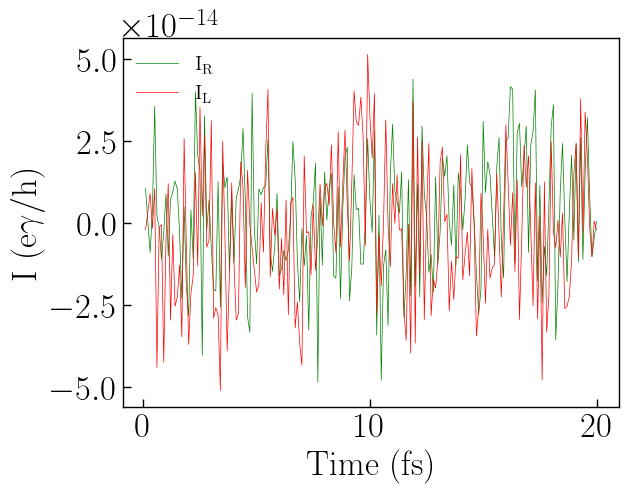

In [314]:
fig,axs = plt.subplots(1,1)
fs=25
#*1000000*1.25/2pi
axs.plot(ts_cc,-cc_αt[1,:]*4pi,color= "green",lw = 0.5,label = raw"$\mathrm{I_R}$")
axs.plot(ts_cc,-cc_αt[2,:]*4pi,color= "red",lw = 0.5,label = raw"$\mathrm{I_L}$")
axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#plt.xlim(0.0,250)
# plt.axhline(0.1,ls = "--",lw=0.5)
# plt.axhline(-0.1,ls = "--",lw=0.5)
# plt.axhline(0.0,ls = "--",lw=0.5)
#plt.axhline(0.05,ls = "--",lw=0.5)
#plt.xlim(90,120)
#plt.ylim(-2,6.5)
#plt.ylim(-0.,0.1)
#plt.ylim(0.1-1e-1,0.1+1e-1)
#plt.ylim(-0.1,0.1)
#plt.ylim(0,0.8)
#plt.xlim(0,23)
#plt.ylim(-1,1)
plt.show()

In [315]:
#sc_αxt

### Spin Current 

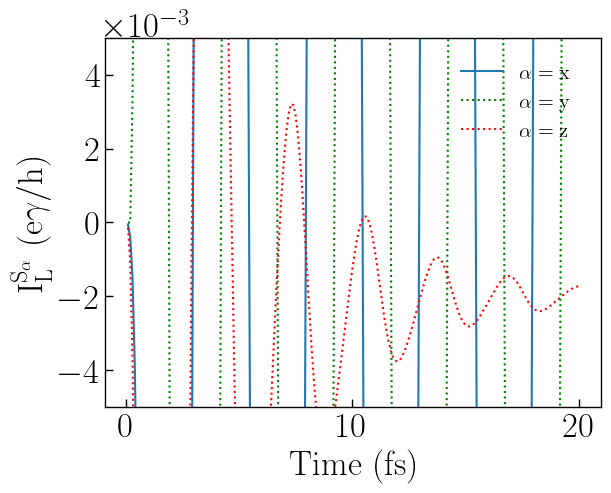

PyObject <matplotlib.legend.Legend object at 0x7fab185cecc0>

In [321]:
fig,axs = plt.subplots(1,1)
site = 1
axs.plot(ts_sc,-sc_αxt[site,1,:], label = raw"$\mathrm{\alpha = x}$")
axs.plot(ts_sc,-sc_αxt[site,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":",color="green")
axs.plot(ts_sc,-sc_αxt[site,3,:], label = raw"$\mathrm{\alpha = z}$",color="red",ls=":")

# axs.plot(ts_sc,sc_αxt[2,1,:], label = raw"$\mathrm{\alpha = x}$")
# axs.plot(ts_sc,sc_αxt[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
# axs.plot(ts_sc,sc_αxt[2,3,:], label = raw"$\mathrm{\alpha = z}$")
axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#plt.xlim(98,120)
#plt.ylim(-1,1)
#plt.ylim(-0.25,0.25)
plt.ylim(-0.005,0.005)
#plt.xlim([0,22])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))

### Spin density

In [322]:
#sneq_ta1x[:,site,3]
#nx
#sneq_ta1x[:,:,3]

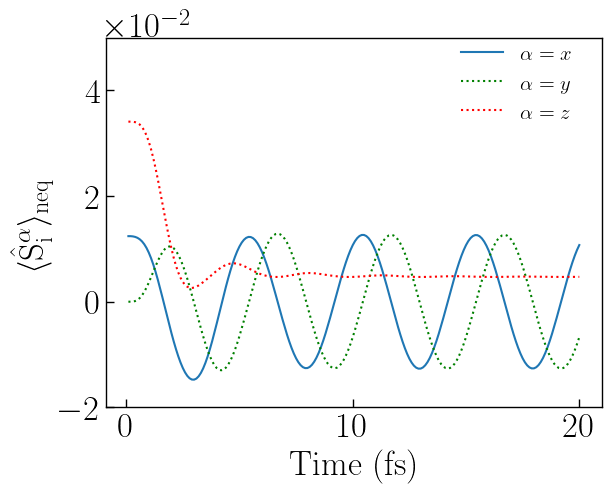

PyObject <matplotlib.legend.Legend object at 0x7fab18638a70>

In [323]:
fig,axs = plt.subplots(1,1)
fs=25
site = 2
mag = sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2
axs.plot(ts_sn,sneq_ta1x[:,site,1],label = raw"$\alpha=x$")
axs.plot(ts_sn,sneq_ta1x[:,site,2],label = raw"$\alpha=y$",color="green",ls=":")
axs.plot(ts_sn,sneq_ta1x[:,site,3],label = raw"$\alpha=z$",color="red",ls=":")
#plt.axhline(0.05,ls = "--",lw=0.5)
#plt.axhline(-0.05,ls = "--",lw=0.5)
axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{neq}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#plt.xlim(90,100)
#plt.xlim(98,120)
#plt.ylim(-1,1)
plt.ylim(-2e-2,5e-2)
#plt.xlim([0,22])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))

In [217]:
ts_sn

0.1:0.1:20.0

In [218]:
#cden_ta1[:,1] + cden_ta1[:,2]

In [219]:
# fig,axs =  plt.subplots(1,1)
# site = 1
# sites = range(1,6)
# # for i in site 
# #     axs.plot(ts_cd, cden_ta1[:,i]*det,label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
# #     axs.plot(ts_cd, cden_ta1[:,i+1]*det,label= "site=$(i+1)")#
# # end
# axs.plot(ts_cd/hbar, cden_ta1[:,1]+cden_ta1[:,2],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
# axs.plot(ts_cd/hbar, cden_ta1[:,3]+cden_ta1[:,4],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
# plt.ylim(0.5-0.5,0.5+0.5)

### Local density 

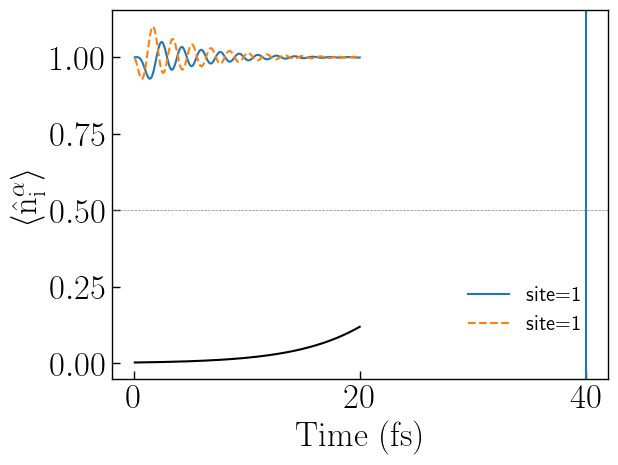

PyObject <matplotlib.lines.Line2D object at 0x7fab1b6ae660>

In [220]:
fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
# for i in site 
#     axs.plot(ts_cd, cden_ta1[:,i]*det,label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
#     axs.plot(ts_cd, cden_ta1[:,i+1]*det,label= "site=$(i+1)")#
# end
stepp(t;ti=40) = t < ti ? sin((pi/2)*t/ti)^2 : 1.0
stepp(t;t_c=30,a=0.1) = 0.5 * (tanh(a * (t - t_c)) + 1)


axs.plot(ts_cd/hbar, cden_ta1[:,1]+cden_ta1[:,2],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
axs.plot(ts_cd/hbar, cden_ta1[:,3]+cden_ta1[:,4],label= "site=$(1)",ls="--")#,alpha =1-0.2*i ) ### Charge bound current

axs.plot(ts_cd,stepp.(ts_cd),color="black")

#axs.plot(ts_cd/hbar, cden_ta1[:,3]+cden_ta1[:,4],label= "site=$(2)",ls="--")#(cden_ta1[:,4]+cden_ta1[:,3]),label= "site=$(2)")

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(-1,100)
plt.axhline(0.5,ls = "--",color="gray",lw = 0.5)
plt.axvline(40)
#plt.axhline(1.)
# plt.xlim(0,20)
# plt.ylim(0,1.0)
#plt.ylim(-0.6,0.6)
# plt.ylim(1-0.01,1+0.01)
# plt.ylim(0.5-0.5,0.5+0.5)
#plt.ylim(-1e-6,1e-6)

In [299]:
cden_ta1#[:,1]

200×4 Matrix{Float64}:
 0.503405  0.496595  0.523396  0.476604
 0.503405  0.496595  0.523396  0.476604
 0.503404  0.496596  0.523402  0.476598
 0.503403  0.496597  0.523413  0.476587
 0.503399  0.496601  0.523427  0.476573
 0.50339   0.49661   0.523443  0.476557
 0.503375  0.496625  0.523455  0.476545
 0.503352  0.496648  0.523463  0.476537
 0.503319  0.496681  0.523461  0.476539
 0.503277  0.496723  0.523447  0.476553
 0.503226  0.496774  0.523417  0.476583
 0.503167  0.496833  0.523368  0.476632
 0.503101  0.496899  0.523297  0.476703
 ⋮                             
 0.50181   0.49819   0.522788  0.477212
 0.501836  0.498164  0.522782  0.477218
 0.50186   0.49814   0.522772  0.477228
 0.501881  0.498119  0.522759  0.477241
 0.501899  0.498101  0.522743  0.477257
 0.501914  0.498086  0.522725  0.477275
 0.501926  0.498074  0.522705  0.477295
 0.501935  0.498065  0.522682  0.477318
 0.501941  0.498059  0.522658  0.477342
 0.501945  0.498055  0.522632  0.477368
 0.501945  0.498055  0.52

### Classical magnetization

In [821]:
#cspins_tax
#sneq_ta1x
#.-2pi/10

In [822]:
#.-2pi/10 --> for T=5
#2pi/(2pi/2.3 -pi)
#2pi/2
#cspins_tax

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


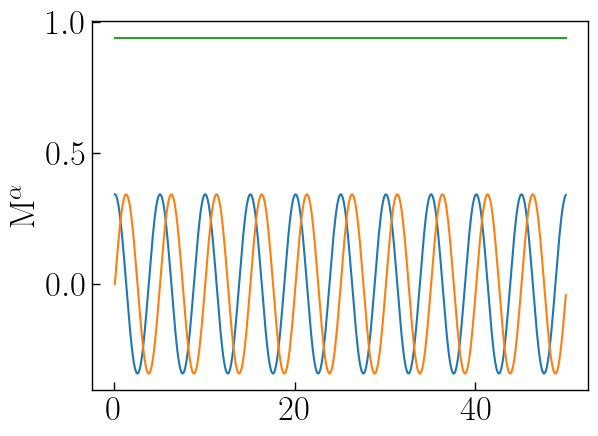

In [823]:
fig,axs = plt.subplots(1,1)
fs=25
site = 1
axs.plot(ts_cs ,cspins_tax[:,site,1])
axs.plot(ts_cs,cspins_tax[:,site,2])
axs.plot(ts_cs,cspins_tax[:,site,3])

#axs.plot(ts_sn  ,-sneq_ta1x[:,site,1]*10,label = raw"$\alpha=x$")
#axs.plot(ts_sn ,sneq_ta1x[:,site,2]*20,label = raw"$\alpha=y$")


#axs.plot(ts_sn,sneq_f[1:2:end,2]*20,label = raw"$\alpha=x$",":")
# axs.plot(ts_sn,sneq_f[2:2:end,2]*20,label = raw"$\alpha=y$",":")
#axs.plot(ts_sn,sneq_f[1:2:end,3]*20,label = raw"$\alpha=z$",":")
#axs.plot(ts_cs,cspins_tax[:,site+2,3])
axs.set_ylabel(L"$\mathrm{M^{\alpha}}$", fontsize = fs)
#axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([-5e-1,+5e-1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([350,800])
#axs.set_xlim([950,1050])
#axs.set_xlim([100,120])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.show()
#axs.set_xlim(1800,2100)

In [362]:
#sneq_f
2pi/0.6



10.471975511965978

In [51]:
sneq_f

1600×3 Matrix{Float64}:
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 ⋮         
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0

## Save data

In [47]:
using DelimitedFiles
path = "/home/jalil2/Documents/KBA/data"
name = "GKBA_33"#"GKBA"

"GKBA_33"

In [48]:
sd = [sneq_ta1x[:,1,1] sneq_ta1x[:,1,2] sneq_ta1x[:,1,3] sneq_ta1x[:,2,1] sneq_ta1x[:,2,2] sneq_ta1x[:,2,3]]
sc = [sc_αxt[1,1,:] sc_αxt[1,2,:] sc_αxt[1,3,:] sc_αxt[2,1,:] sc_αxt[2,2,:] sc_αxt[2,3,:] ]

1200×6 Matrix{Float64}:
 -0.000120409  -9.72494e-18  -0.000330821  …  -9.43578e-18  -0.000330821
 -0.000941692  -8.18398e-5   -0.0026025       -8.18398e-5   -0.0026025
 -0.00305099   -0.000520127  -0.00854712      -0.000520127  -0.00854712
 -0.00680501   -0.0017431    -0.0194789       -0.0017431    -0.0194789
 -0.0122516    -0.00424589   -0.0361394       -0.00424589   -0.0361394
 -0.0190952    -0.00848565   -0.0585919    …  -0.00848565   -0.0585919
 -0.0267133    -0.0147754    -0.0861793       -0.0147754    -0.0861793
 -0.0342211    -0.0231935    -0.11755         -0.0231935    -0.11755
 -0.0405759    -0.0335243    -0.150749        -0.0335243    -0.150749
 -0.0447072    -0.0452396    -0.183373        -0.0452396    -0.183373
 -0.0456522    -0.057525     -0.212766     …  -0.057525     -0.212766
 -0.0426814    -0.0693494    -0.236245        -0.0693494    -0.236245
 -0.0353944    -0.0795677    -0.251343        -0.0795677    -0.251343
  ⋮                                        ⋱             

In [49]:
#sneq_ta1x[:,1,1] 
#sneq_ta1x

### Spin density

In [50]:
#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
sd_f = open("$(path)/sd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sd_f, [ts_sn sd], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sd_f)

### Spin current 

In [51]:
sc_f = open("$(path)/sc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sc_f, [ts_sc sc], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sc_f)

In [52]:
#cc_αt[:,:]'
#ts_sneq

#sc_αt

### Charge current 


In [53]:

#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
cc_f = open("$(path)/cc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cc_f, [ts_cc -4*pi*cc_αt'], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(cc_f)

### Local density 

In [44]:
#using DelimitedFiles
#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
cden_f = open("$(path)/cd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cden_f, [ts_cd cden_ta1], ' ' )
#close(ccL_f)
close(cden_f)

In [38]:
#cden_ta1